# Earth2Studio: AI Weather Forecasting

This notebook demonstrates NVIDIA Earth2Studio for:
1. **2m Temperature** forecast (FCN)
2. **10m Wind Speed & MSLP** forecasts (SFNO)
3. **Hurricane Florence track comparison** (GraphCast vs FCN vs ERA5 reanalysis)
4. **850 hPa Moisture** visualization (GraphCast)

### Prerequisites
- Python 3.12 with the `earth2` kernel
- `uv sync` (resolves all Earth2Studio extras)
- NVIDIA GPU with CUDA

---
## Imports & Config

In [1]:
import os
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm

import earth2studio.run as run
from earth2studio.models.px import FCN, SFNO, GraphCastOperational
from earth2studio.models.dx import TCTrackerWuDuan
from earth2studio.data import GFS, WB2ERA5, NCAR_ERA5, fetch_data, prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PROJECT_DIR = Path("/home/jovyan/Earth2")
os.chdir(PROJECT_DIR)

print(f"Device: {DEVICE}")

/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jovyan/Earth2/.venv/lib/python3.12/site-packages/cupy/_environment.py:663: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy-cuda12x, cupy-cuda13x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the follow

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this featureDevice: cuda

## 2m Air Temperature Forecast

In [2]:
model = FCN.load_model(FCN.load_default_package())
data = GFS()

t2m_path = PROJECT_DIR/"t2m_outputs/fcn_gfs_forecast.zarr"
io = ZarrBackend(str(t2m_path), backend_kwargs={"overwrite": True})

io = run.deterministic(["2026-01-08"], 10, model, data, io)
print(io.root.tree())

2026-05-18 19:50:50.795 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-18 19:50:50.795 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-18 19:50:53.884 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 414147575-944928
2026-05-18 19:50:53.889 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 253820556-806142
2026-05-18 19:50:53.891 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 398557080-950478
2026-05-18 19:50:53.893 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 413181533-966042
2026-05-18 19:50:53.894 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260108/00/atmos/gfs.t00z.pgrb2.0p25.f000 331385039-869528
2026-05-18 19:50:53.896 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:02<00:00, 11.52it/s]

2026-05-18 19:50:56.199 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-05-18 19:50:56.389 | INFO     | earth2studio.run:deterministic:139 - Inference starting!

Running inference: 100%|██████████| 11/11 [00:19<00:00,  1.74s/it]

2026-05-18 19:51:15.514 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (720,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 720, 1440) float32
├── r500 (1, 11, 720, 1440) float32
├── r850 (1, 11, 720, 1440) float32
├── sp (1, 11, 720, 1440) float32
├── t250 (1, 11, 720, 1440) float32
├── t2m (1, 11, 720, 1440) float32
├── t500 (1, 11, 720, 1440) float32
├── t850 (1, 11, 720, 1440) float32
├── tcwv (1, 11, 720, 1440) float32
├── time (1,) datetime64[ns]
├── u1000 (1, 11, 720, 1440) float32
├── u100m (1, 11, 720, 1440) float32
├── u10m (1, 11, 720, 1440) float32
├── u250 (1, 11, 720, 1440) float32
├── u500 (1, 11, 720, 1440) float32
├── u850 (1, 11, 720, 1440) float32
├── v1000 (1, 11, 720, 1440) float32
├── v100m (1, 11, 720, 1440) float32
├── v10m (1, 11, 720, 1440) float32
├── v250 (1, 11, 720, 1440) float32
├── v500 (1, 11, 720, 1440) float32
├── v850 (1, 11, 720, 1440) float32
├── z1000 (1, 11, 720, 1440) float32


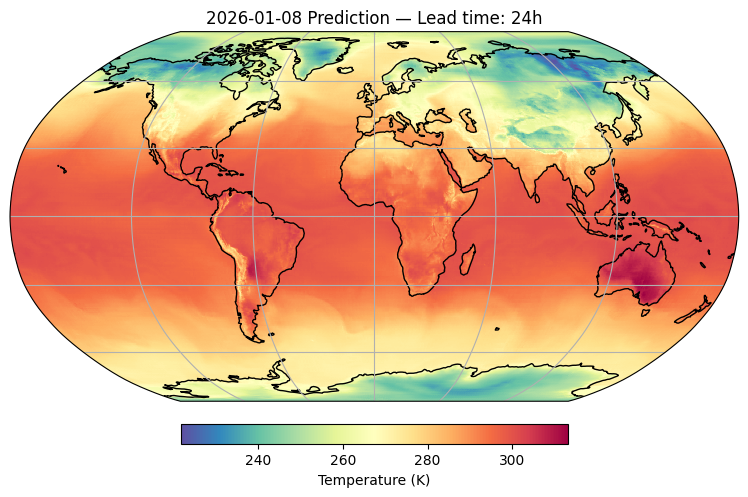

In [4]:
def plot_t2m(zarr_path, variable, step, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    projection = ccrs.Robinson()

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))
    im = ax.pcolormesh(
        ds["lon"], ds["lat"], ds[variable][0, step],
        transform=ccrs.PlateCarree(), cmap="Spectral_r",
    )
    plt.colorbar(
            im, 
            ax=ax, 
            orientation="horizontal", 
            pad=0.05, 
            label="Temperature (K)",
            shrink=0.5,  
            aspect=20
)

    ax.set_title(f"2026-01-08 Prediction — Lead time: {6 * step}h")
    ax.coastlines()
    ax.gridlines()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_t2m(t2m_path, "t2m", step=4, save_path=PROJECT_DIR / "t2m_outputs/t2m_prediction.jpg")

---
## 10m Wind Speed & MSLP Forecasts (SFNO)

In [5]:
sfno_model = SFNO.load_model(SFNO.load_default_package())
data = GFS()

sfno_path = PROJECT_DIR / "sfno_outputs/sfno_gfs_forecast.zarr"
sfno_path.parent.mkdir(parents=True, exist_ok=True)
io = ZarrBackend(str(sfno_path), backend_kwargs={"overwrite": True})

io = run.deterministic(["2026-01-01"], 10, sfno_model, data, io)
print(io.root.tree())

2026-05-18 20:00:30.847 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-18 20:00:30.847 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda

Unclosed client session
Fetching GFS data:   0%|          | 0/73 [00:00<?, ?it/s]

2026-05-18 20:00:32.825 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 421153101-970715
2026-05-18 20:00:32.827 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 180067903-910623
2026-05-18 20:00:32.829 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 367926743-957726
2026-05-18 20:00:32.830 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 205551634-750666
2026-05-18 20:00:32.833 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260101/00/atmos/gfs.t00z.pgrb2.0p25.f000 280687436-849091
2026-05-18 20:00:32.834 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data: 100%|██████████| 73/73 [00:02<00:00, 35.04it/s]

2026-05-18 20:00:35.134 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from GFS
2026-05-18 20:00:35.316 | INFO     | earth2studio.run:deterministic:139 - Inference starting!

Running inference: 100%|██████████| 11/11 [01:21<00:00,  7.42s/it]

2026-05-18 20:01:56.939 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
/
├── lat (721,) float64
├── lead_time (11,) timedelta64[h]
├── lon (1440,) float64
├── msl (1, 11, 721, 1440) float32
├── q100 (1, 11, 721, 1440) float32
├── q1000 (1, 11, 721, 1440) float32
├── q150 (1, 11, 721, 1440) float32
├── q200 (1, 11, 721, 1440) float32
├── q250 (1, 11, 721, 1440) float32
├── q300 (1, 11, 721, 1440) float32
├── q400 (1, 11, 721, 1440) float32
├── q50 (1, 11, 721, 1440) float32
├── q500 (1, 11, 721, 1440) float32
├── q600 (1, 11, 721, 1440) float32
├── q700 (1, 11, 721, 1440) float32
├── q850 (1, 11, 721, 1440) float32
├── q925 (1, 11, 721, 1440) float32
├── sp (1, 11, 721, 1440) float32
├── t100 (1, 11, 721, 1440) float32
├── t1000 (1, 11, 721, 1440) float32
├── t150 (1, 11, 721, 1440) float32
├── t200 (1, 11, 721, 1440) float32
├── t250 (1, 11, 721, 1440) float32
├── t2m (1, 11, 721, 1440) float32
├── t300 (1, 11, 721, 1440) float32
├── t400 (1, 11, 721, 1440) float

In [19]:
def plot_sfno_10m_wind(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    ws10 = np.sqrt(ds["u10m"][0, step] ** 2 + ds["v10m"][0, step] ** 2)
    projection = ccrs.Robinson()
    levels = np.arange(0, 40, 2)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], ws10, levels,
        transform=ccrs.PlateCarree(), cmap="YlOrRd", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="10 m Wind Speed (m/s)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — 10 m Wind Speed — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()


def plot_sfno_msl(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    msl_hpa = ds["msl"][0, step] / 100.0
    projection = ccrs.Robinson()
    levels = np.arange(960, 1045, 4)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], msl_hpa, levels,
        transform=ccrs.PlateCarree(), cmap="jet", extend="neither",
    )
    plt.colorbar(im, ax=ax, shrink=0.5, pad=0.04, label="Mean Sea Level Pressure (hPa)", orientation="horizontal")
    ax.set_title(f"SFNO — 2026-01-01 — MSLP — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

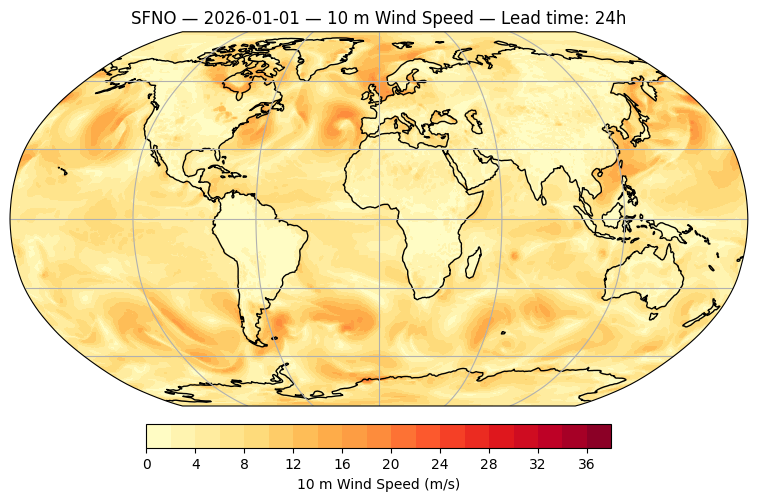

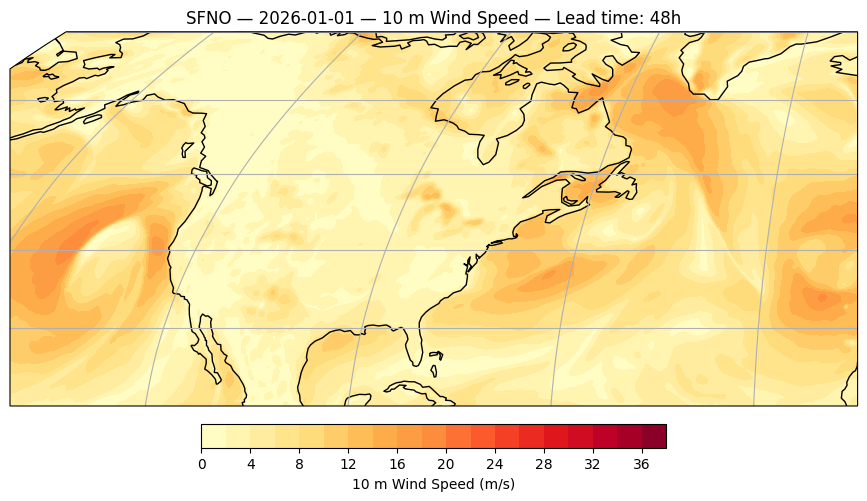

In [20]:
# 10m wind speed
plot_sfno_10m_wind(sfno_path, step=4)
plot_sfno_10m_wind(sfno_path, step=8, extent=[220, 340, 20, 70])

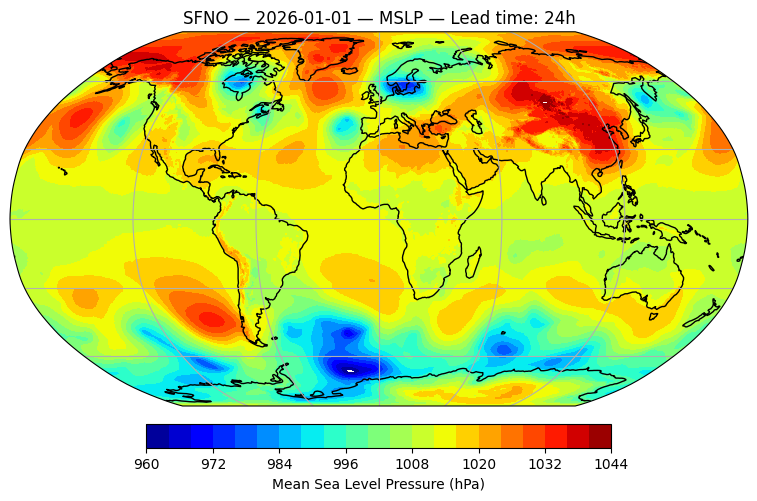

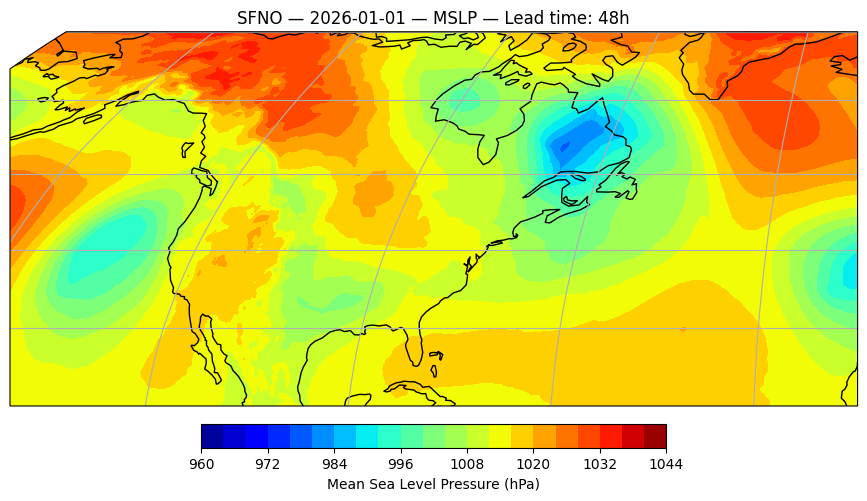

In [21]:
# Mean sea level pressure
plot_sfno_msl(sfno_path, step=4)
plot_sfno_msl(sfno_path, step=8, extent=[220, 340, 20, 70])

## Hurricane Florence Track Comparison

Compare tropical cyclone tracks from GraphCast, FCN, and ERA5 reanalysis for Hurricane Florence (September 2018).

In [22]:
FLORENCE_DIR = PROJECT_DIR / "florence_outputs"
FLORENCE_DIR.mkdir(exist_ok=True)

START_TIME = datetime(2018, 9, 13)
NSTEPS = 25
END_TIME = START_TIME + timedelta(hours=6 * NSTEPS)

### Inference helper

In [23]:
def run_tc_inference(prognostic, data_source, tracker, start_time, nsteps, save_path):
    """Run a prognostic model through the TC tracker and save the resulting tracks."""
    prognostic = prognostic.to(DEVICE)
    tracker.reset_path_buffer()

    x, coords = fetch_data(
        source=data_source,
        time=to_time_array([start_time]),
        variable=prognostic.input_coords()["variable"],
        lead_time=prognostic.input_coords()["lead_time"],
        device=DEVICE,
    )
    x, coords = map_coords(x, coords, prognostic.input_coords())

    iterator = prognostic.create_iterator(x, coords)
    for step, (x, coords) in tqdm(enumerate(iterator), total=nsteps + 1):
        x, coords = map_coords(x, coords, tracker.input_coords())
        output, _ = tracker(x, coords)
        output = output[:, 0]
        if step == nsteps:
            break

    tracks = output.cpu()
    torch.save(tracks, str(save_path))
    print(f"Saved: {save_path}")
    return tracks

### 3a — GraphCast Operational

In [25]:
graphcast_model = GraphCastOperational.load_model(GraphCastOperational.load_default_package())
wb2_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()

graphcast_tracks = run_tc_inference(
    graphcast_model, wb2_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "graphcast_operational_paths.pt",
)

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Earth2Studio Extra Dependency Error                                                                             │
│ This error typically indicates an extra dependency group is needed.                                             │
│ Don't panic, this is usually an easy fix.                                                                       │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ This feature ('earth2studio.models.px.graphcast_operational.load_model') is marked needing optional dependency  │
│ group 'graphcast'.                                                                                              │
│                                                                                                                 │
│ uv install with: `uv add earth2studio --extra graphcast`                                                        │
│                                                                                                                 │
│ For more information (such as pip install instructions), visit the install documentation:                       │
│ https://nvidia.github.io/earth2studio/userguide/about/install.html#optional-dependencies                        │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ ╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮            │
│ │ /home/jovyan/Earth2/.venv/lib/python3.12/site-packages/earth2studio/models/px/graphcast_operati… │            │
│ │ in <module>                                                                                      │            │
│ │                                                                                                  │            │
│ │    36 from earth2studio.utils.type import CoordSystem                                            │            │
│ │    37                                                                                            │            │
│ │    38 try:                                                                                       │            │
│ │ ❱  39 │   import chex                                                                            │            │
│ │    40 │   import haiku as hk                                                                     │            │
│ │    41 │   import jax                                                                             │            │
│ │    42 │   from graphcast import (                                                                │            │
│ ╰──────────────────────────────────────────────────────────────────────────────────────────────────╯            │
│ ImportError: No module named 'chex'                                                                             │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

OptionalDependencyError: Optional dependency import error

### 3b — ERA5 Reanalysis (ground truth)

In [9]:
era5_data = WB2ERA5(cache=True, verbose=True)
tracker = TCTrackerWuDuan()
tracker.reset_path_buffer()

times = [START_TIME + timedelta(hours=6 * i) for i in range(NSTEPS + 1)]
for step, time in tqdm(enumerate(times), total=len(times)):
    da = era5_data(time, tracker.input_coords()["variable"])
    x, coords = prep_data_array(da, device=DEVICE)
    output, _ = tracker(x, coords)

era5_tracks = output.cpu()
torch.save(era5_tracks, str(FLORENCE_DIR / "era5_paths.pt"))
print("Saved ERA5 tracks")

NameError: name 'NSTEPS' is not defined

### 3c — FCN

In [11]:
fcn_model = FCN.load_model(FCN.load_default_package())
fcn_data = NCAR_ERA5()
tracker = TCTrackerWuDuan()

fcn_tracks = run_tc_inference(
    fcn_model, fcn_data, tracker,
    START_TIME, NSTEPS, FLORENCE_DIR / "fcn_paths.pt",
)

NameError: name 'run_tc_inference' is not defined

### 3d — Plot Track Comparison

In [12]:
def add_cities(ax, city_list, offset=(0.22, 0.22)):
    """Annotate cities on a cartopy axis. Each entry: (name, lat, lon[, dx, dy])."""
    text_kw = dict(
        fontsize=8, zorder=11, transform=ccrs.PlateCarree(),
        path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )
    for item in city_list:
        name, lat, lon = item[0], item[1], item[2]
        dx, dy = (item[3], item[4]) if len(item) == 5 else offset
        ax.plot(lon, lat, "o", color="red", markersize=3, zorder=10, transform=ccrs.PlateCarree())
        ax.text(lon + dx, lat + dy, name, **text_kw)


def plot_hurricane_tracks(models, start_time=None, end_time=None,
                          extent=(-95, -60, 30, 45), cities=None,
                          title="Tropical Cyclone Tracks", save_path=None):
    """Plot one or more TC track sets on a single map."""
    projection = ccrs.Robinson()
    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 8))

    ax.add_feature(cfeature.LAND, alpha=0.1)
    ax.add_feature(cfeature.STATES, linewidth=0.5, alpha=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.2)
    ax.set_extent(extent)

    for m in models:
        tracks = m["tracks"]
        if hasattr(tracks, "detach"):
            tracks = tracks.detach().cpu().numpy()

        label_set = False
        for p in range(tracks.shape[1]):
            lats, lons = tracks[0, p, :, 0], tracks[0, p, :, 1]
            mask = ~np.isnan(lats) & ~np.isnan(lons)
            if mask.sum() > 2:
                ax.plot(
                    lons[mask], lats[mask],
                    color=m.get("color"), linewidth=m.get("lw", 2),
                    linestyle=m.get("ls", "--"),
                    label=m["name"] if not label_set else "",
                    transform=ccrs.PlateCarree(), zorder=6,
                )
                label_set = True

    if cities:
        add_cities(ax, cities)

    if start_time and end_time:
        ax.set_title(f"{title}\n{start_time:%Y-%m-%d} to {end_time:%Y-%m-%d}")
    else:
        ax.set_title(title)

    ax.legend(loc="lower right", title="Models")
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

In [13]:
# Load saved tracks (or use variables from cells above)
era5_load = torch.load(FLORENCE_DIR / "era5_paths.pt", map_location="cpu")
graphcast_load = torch.load(FLORENCE_DIR / "graphcast_operational_paths.pt", map_location="cpu")
fcn_load = torch.load(FLORENCE_DIR / "fcn_paths.pt", map_location="cpu")

cities = [
    ("Charlotte", 35.2271, -80.8431,  0.18, -0.18),
    ("Raleigh", 35.7796, -78.6382,  0.18,  0.18),
    ("Charleston", 32.7765, -79.9311, -0.35,  0.15),
    ("Atlanta", 33.7490, -84.3880,  0.18,  0.18),
    ("Richmond", 37.5407, -77.4360,  0.18, -0.18),
    ("Philadelphia", 39.9526, -75.1652,  0.18, -0.18),
    ("New York City", 40.7685, -73.9822,  0.18, -0.18),
]

models = [
    {"name": "ERA5", "tracks": era5_load, "color": "#1f77b4", "lw": 3.0, "ls": "-"},
    {"name": "GraphCast", "tracks": graphcast_load, "color": "#ff7f0e", "lw": 2.0, "ls": "--"},
    {"name": "FCN", "tracks": fcn_load, "color": "#2ca02c", "lw": 2.0, "ls": "-."},
]

plot_hurricane_tracks(
    models,
    start_time=START_TIME, end_time=END_TIME,
    extent=(-90, -65, 31, 41),
    cities=cities,
)

NameError: name 'FLORENCE_DIR' is not defined

## 850 hPa Moisture Visualization (GraphCast)

In [18]:
model = GraphCastOperational.load_model(GraphCastOperational.load_default_package())
data = GFS()

tcwv_path = PROJECT_DIR / "tcwv_outputs/graphcast_tcwv_forecast.zarr"
tcwv_path.parent.mkdir(parents=True, exist_ok=True)
io = ZarrBackend(str(tcwv_path), backend_kwargs={"overwrite": True})

io = run.deterministic(["2024-09-26"], 16, model, data, io)
print(io.root.tree())

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Earth2Studio Extra Dependency Error                                                                             │
│ This error typically indicates an extra dependency group is needed.                                             │
│ Don't panic, this is usually an easy fix.                                                                       │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ This feature ('earth2studio.models.px.graphcast_operational.load_model') is marked needing optional dependency  │
│ group 'graphcast'.                                                                                              │
│                                                                                                                 │
│ uv install with: `uv add earth2studio --extra graphcast`                                                        │
│                                                                                                                 │
│ For more information (such as pip install instructions), visit the install documentation:                       │
│ https://nvidia.github.io/earth2studio/userguide/about/install.html#optional-dependencies                        │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ ╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮            │
│ │ /home/jovyan/Earth2/.venv/lib/python3.12/site-packages/earth2studio/models/px/graphcast_operati… │            │
│ │ in <module>                                                                                      │            │
│ │                                                                                                  │            │
│ │    36 from earth2studio.utils.type import CoordSystem                                            │            │
│ │    37                                                                                            │            │
│ │    38 try:                                                                                       │            │
│ │ ❱  39 │   import chex                                                                            │            │
│ │    40 │   import haiku as hk                                                                     │            │
│ │    41 │   import jax                                                                             │            │
│ │    42 │   from graphcast import (                                                                │            │
│ ╰──────────────────────────────────────────────────────────────────────────────────────────────────╯            │
│ ImportError: No module named 'chex'                                                                             │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

OptionalDependencyError: Optional dependency import error

In [17]:
def plot_moisture(zarr_path, step, extent=None, save_path=None):
    ds = xr.open_zarr(str(zarr_path))
    q850 = ds["q850"][0, step] * 1000  # convert kg/kg to g/kg
    projection = ccrs.Robinson()
    levels = np.arange(0, 18, 1)

    fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(12, 6))
    im = ax.contourf(
        ds["lon"], ds["lat"], q850, levels,
        transform=ccrs.PlateCarree(), cmap="GnBu", extend="neither",
    )
    plt.colorbar(im, ax=ax, orientation="horizontal", shrink=0.55, pad=0.05,
                 label="Specific Humidity at 850 hPa (g/kg)", aspect = 30)
    ax.set_title(f"GraphCast — 2024-09-26 — 850 hPa Moisture — Lead time: {6 * step}h")
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines()
    if save_path:
        plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()

In [16]:
# Global view
plot_moisture(tcwv_path, step=4)

# Gulf Coast
plot_moisture(tcwv_path, step=8, extent=[-100, -70, 15, 40])

# Western Pacific tropical moisture
plot_moisture(tcwv_path, step=8, extent=[100, 160, 0, 40])

NameError: name 'plot_moisture' is not defined